#Creting a chatbot using LangGraph and Groq LLM
#In this tutorial, we will create a simple chatbot using LangGraph and Groq LLM. We will define a state graph for the chatbot, where the chatbot will take user input and generate a response using the Groq LLM.

In [ ]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph ,START, END 
from typing import TypedDict , Annotated , operator ,Literal
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage,HumanMessage,BaseMessage
from langgraph.checkpoint.memory import MemorySaver
import operator 
from dotenv import load_dotenv
load_dotenv(override=True)
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm_model=ChatGroq(model="llama-3.1-8b-instant")


In [3]:
from langgraph.graph.message import add_messages   
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [4]:
def chat_node(state:ChatState):
    #take user query from state
    messages = state['messages']

    

    #send to llm
    response = llm_model.invoke(messages)



    #respohnse store state
    return {'messages' : [response]}

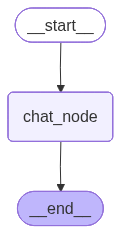

In [10]:
#checkpointer to save the conversation history - you can also use other checkpointer like FileSaver, RedisSaver etc.
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpointer)
chatbot


In [6]:
initial_state = {
    'messages' : [HumanMessage(content="What is the capital of Nepal?")]

}
chatbot.invoke(initial_state)['messages'][-1].content

'The capital of Nepal is Kathmandu.'

In [18]:
#thread id is used to identify the conversation history in the checkpointer,
#you can use any unique identifier for the conversation

thread_id = '1'

while True:

  user_message =   input('AI ChatBot: Type Here Your Query : ')
  print('User : ', user_message)
  if user_message.strip().lower() in [ 'exit','quit','bye']:
    print("Exiting the chatbot. Goodbye!")
    break

  config = {'configurable':{'thread_id': thread_id}}  
  response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
  print('AI : ', response['messages'][-1].content)

User :  hi i am vijay
AI :  Nice to meet you Vijay again. What brings you back today?
User :  
AI :  It looks like you might have stopped typing. Is there something else you'd like to talk about or ask?
User :  exit
Exiting the chatbot. Goodbye!


In [ ]:
#To get the conversation history from the checkpointer, 
# you can use the `get_state` method of the chatbot with the same thread_id used for saving the conversation history.
chatbot.get_state(config=config)


StateSnapshot(values={'messages': [HumanMessage(content='Hi i am vijay', additional_kwargs={}, response_metadata={}, id='7c9de0eb-67c7-4b8c-af80-d6ccf7d993ec'), AIMessage(content='Nice to meet you Vijay. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 41, 'total_tokens': 56, 'completion_time': 0.205714687, 'completion_tokens_details': None, 'prompt_time': 0.003703457, 'prompt_tokens_details': None, 'queue_time': 0.067759463, 'total_time': 0.209418144}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb5a6-fa8e-7f50-938b-e14198118949-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 15, 'total_tokens': 56}), HumanMessage(content='tell me my name', additional_kwargs={}, response_metadata={}, id='5af5e08a-636c-4d2b-a481-5d29